In [4]:
!pip install torch torchvision --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
data_dir = "/kaggle/input/datasets/venkatsaikondra/venkatsaikondra67/Final_Data"

In [7]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [8]:
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=val_transform)
test_dataset = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

class_names = train_dataset.classes
print("Classes:", class_names)

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [9]:
labels = train_dataset.targets
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

In [10]:
model = models.squeezenet1_1(pretrained=True)

# Modify classifier
model.classifier[1] = nn.Conv2d(512, len(class_names), kernel_size=(1,1))
model.num_classes = len(class_names)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 105MB/s]


In [11]:
for param in model.features.parameters():
    param.requires_grad = False

In [12]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.3
)

In [13]:
def train_model(model, train_loader, val_loader, epochs=30):
    best_f1 = 0.0
    scaler = torch.cuda.amp.GradScaler()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, preds = torch.max(outputs, 1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(labels.cpu().numpy())

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = (np.array(val_preds) == np.array(val_labels)).mean()
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        scheduler.step(val_f1)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), "best_model_squeezenet.pth")

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Best F1: {best_f1:.4f}")
        print("-"*50)

    model.load_state_dict(torch.load("best_model_squeezenet.pth"))
    return model

In [14]:
model = train_model(model, train_loader, val_loader, epochs=10)

/tmp/ipykernel_55/2136879503.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/10
Train Loss: 0.9958 | Train Acc: 0.5832
Val Loss: 0.6451 | Val Acc: 0.7537 | Val F1: 0.7472
Best F1: 0.7472
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/10
Train Loss: 0.6196 | Train Acc: 0.7537
Val Loss: 0.5495 | Val Acc: 0.7896 | Val F1: 0.7819
Best F1: 0.7819
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 8/10
Train Loss: 0.4653 | Train Acc: 0.8131
Val Loss: 0.4485 | Val Acc: 0.8181 | Val F1: 0.8153
Best F1: 0.8194
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 9/10
Train Loss: 0.4613 | Train Acc: 0.8125
Val Loss: 0.4750 | Val Acc: 0.8045 | Val F1: 0.8010
Best F1: 0.8194
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 10/10
Train Loss: 0.4503 | Train Acc: 0.8227
Val Loss: 0.4461 | Val Acc: 0.8205 | Val F1: 0.8214
Best F1: 0.8214
--------------------------------------------------


In [15]:
for param in model.features[-2:].parameters():
    param.requires_grad = True

In [16]:
model = train_model(model, train_loader, val_loader, epochs=20)

/tmp/ipykernel_55/2136879503.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1/20
Train Loss: 0.4571 | Train Acc: 0.8124
Val Loss: 0.4315 | Val Acc: 0.8255 | Val F1: 0.8281
Best F1: 0.8281
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 2/20
Train Loss: 0.4304 | Train Acc: 0.8233
Val Loss: 0.4381 | Val Acc: 0.8317 | Val F1: 0.8268
Best F1: 0.8281
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 18/20
Train Loss: 0.3035 | Train Acc: 0.8737
Val Loss: 0.3087 | Val Acc: 0.8731 | Val F1: 0.8738
Best F1: 0.8762
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 19/20
Train Loss: 0.2971 | Train Acc: 0.8784
Val Loss: 0.2974 | Val Acc: 0.8806 | Val F1: 0.8806
Best F1: 0.8806
--------------------------------------------------


/tmp/ipykernel_55/2136879503.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 20/20
Train Loss: 0.2973 | Train Acc: 0.8715
Val Loss: 0.3347 | Val Acc: 0.8682 | Val F1: 0.8699
Best F1: 0.8806
--------------------------------------------------


In [17]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

                     precision    recall  f1-score   support

           Covid-19       0.98      1.00      0.99       405
             Normal       0.97      0.94      0.96       405
Pneumonia-Bacterial       0.79      0.73      0.76       405
    Pneumonia-Viral       0.73      0.80      0.76       405

           accuracy                           0.87      1620
          macro avg       0.87      0.87      0.87      1620
       weighted avg       0.87      0.87      0.87      1620



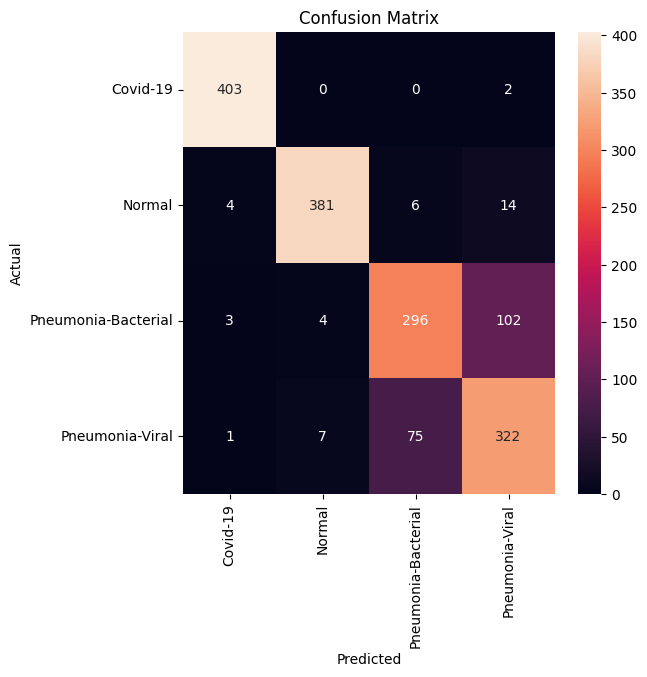

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

In [20]:
model.eval()

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): MaxPool2d

In [22]:
import torch
import numpy as np

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

In [23]:
all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

print(all_probs.shape)   # (N, num_classes)
print(all_labels.shape)  # (N,)

(1620, 4)
(1620,)


In [25]:
num_classes = all_probs.shape[1]

all_labels_bin = label_binarize(all_labels, classes=list(range(num_classes)))

In [26]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

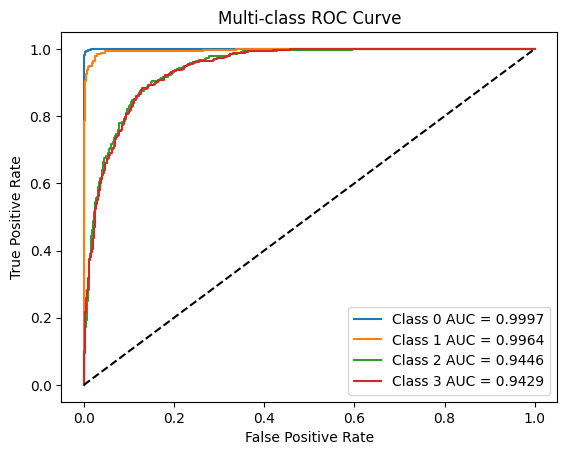

In [27]:
plt.figure()

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} AUC = {roc_auc[i]:.4f}")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.show()

In [28]:
fpr["micro"], tpr["micro"], _ = roc_curve(
    all_labels_bin.ravel(),
    all_probs.ravel()
)

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

print("Micro-average AUC:", roc_auc["micro"])

Micro-average AUC: 0.981228598282782


In [32]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, input_image, class_idx):
        output = self.model(input_image)
        self.model.zero_grad()

        loss = output[0, class_idx]
        loss.backward()

        gradients = self.gradients[0]
        activations = self.activations[0]

        weights = gradients.mean(dim=(1, 2))

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32).to(device)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam.detach().cpu().numpy()

In [33]:
target_layer = model.features[-1]  # adjust if needed
grad_cam = GradCAM(model, target_layer)

In [34]:
sample_img, label = next(iter(test_loader))
sample_img = sample_img[0:1].to(device)

cam = grad_cam.generate(sample_img, label[0].item())

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


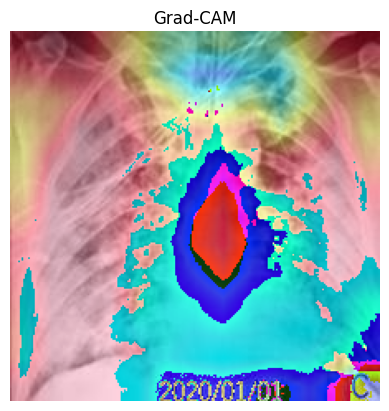

In [35]:
import cv2

img = sample_img.squeeze().permute(1, 2, 0).cpu().numpy()
img = (img - img.min()) / (img.max() - img.min())

heatmap = cv2.resize(cam, (img.shape[1], img.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

superimposed = heatmap * 0.4 + img * 255

plt.imshow(superimposed.astype(np.uint8))
plt.axis('off')
plt.title("Grad-CAM")
plt.show()

In [36]:
class RISE:
    def __init__(self, model, input_size, device):
        self.model = model
        self.input_size = input_size
        self.device = device

    def generate_masks(self, N, s, p1):
        masks = []
        for _ in range(N):
            mask = np.random.rand(s, s) < p1
            mask = mask.astype(np.float32)

            mask = cv2.resize(mask, self.input_size)
            masks.append(mask)

        return np.array(masks)

    def explain(self, image, masks):
        preds = []

        for mask in masks:
            masked_img = image * torch.tensor(mask).to(self.device)
            masked_img = masked_img.unsqueeze(0)

            with torch.no_grad():
                pred = torch.softmax(self.model(masked_img), dim=1)
            preds.append(pred.cpu().numpy())

        preds = np.concatenate(preds)

        saliency = np.zeros(self.input_size)

        for i in range(len(masks)):
            saliency += preds[i, 1] * masks[i]

        saliency = saliency / len(masks)

        return saliency

In [37]:
rise = RISE(model, (224, 224), device)

In [38]:
masks = rise.generate_masks(N=1000, s=8, p1=0.5)

In [39]:
sample_img, label = next(iter(test_loader))
img = sample_img[0].to(device)

saliency = rise.explain(img, masks)

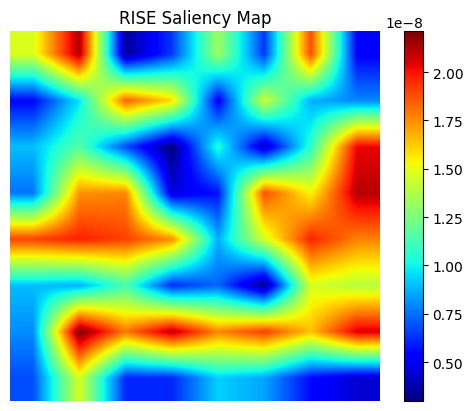

In [40]:
plt.imshow(saliency, cmap='jet')
plt.colorbar()
plt.title("RISE Saliency Map")
plt.axis('off')
plt.show()